#Code companion \#1:  Summer Academy

###Dirk Englund, MIT, USA

###29 July, 2025  


## SPDC Simulation by QuTip

Quantum optics relies on a reliable source of single photons and entangled photon pairs.  A typical source of these photons is spontaneous parametric down-conversion (SPDC) within a nonlinear crystal.    

In this activity, we will simulate the SPDC process and the quantum states of light it generates.  We will do this through the formalism of the degenerate parametric amplifier.  

Specific aims of this activity are:

 * Enrich your understanding of the SPDC process.
 * Develop a realistic model of an SPDC source that could be further extended and used in the context of device and technology simulation and design.


 $
\newcommand{\ket}[1]{\left|#1\right\rangle}
$

## Imports and Headers

Install qutip if needed and import tools for the simulations performed throughout this activity.

In [ ]:
a#Install qutip
!pip install qutip

#Import qutip functions
from qutip import *

#Matplotlib tools for plotting
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm

#Numpy for numerics
import numpy as np
from numpy import *

from IPython.display import display, Math

# Display a ket state using LaTeX
#display(Math(r'\ket{\psi}'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 35.8 MB/s eta 0:00:00


### Operators and Hamiltonian

The SPDC process works by driving a nonlinear crystal with a strong (so that quantum fluctuations can be neglected) at a pump frequency $\omega_p$.  One photon of the pump light is then spontaneously converted into signal and idler photons and frequencies $\omega_s$ and $\omega_i$, respectively. Energy conservation requires that this also corresponds with the growth of an idler wave, and you have that $\omega_p = \omega_s + \omega_i$.  Let's label the signal and idler modes as $a$ and $b$, respectively.

The parametric amplification occurs due to a nonlinear coupling between the fields of the pump, signal, and idler waves.  The coefficient describing the strength of this coupling is the nonlinear coefficient $ \chi^{(2)}$, which is in general complex, but given freedom in choice of phase, we take it as a positive real number here.

Here's the coupling Hamiltonian for the SPDC process:

$$
\hat{H} = i\hbar( \chi^{(2)} \hat{p} \hat{a}^\dagger \hat{b}^\dagger - \chi^{(2)} \hat{p}^\dagger \hat{a} \hat{b})\mbox{,}
$$

where $p$ represents the pump mode.  The left part describes the loss of one pump photon resulting in the increase of one photon in modes $a$ and $b$ (the signal and idler).  The right part represents back conversion from signal and idler to a pump photon.

Given a strong coherent state pump, we can represent its operator via a complex number $\alpha_p$ corresponding to its amplitude. This simplifies the Hamiltonian to

$$
\begin{aligned}
\hat{H}_{ab} = i \hbar \frac{\chi}{2} (\hat{a}^{\dagger} \hat{b}^{\dagger} - \hat{a} \hat{b})
\end{aligned}
$$

where we define

$$
\chi \equiv 2 \chi^{(2)} |\alpha_p|.
$$

Since we can in this case choose the pump's phase arbitrarily, we set it to zero so that $\alpha_p=|\alpha_p|$.  

##  Exercise



Show that $\frac{d\hat{a}}{dt} = \frac{\chi}{2}\hat{b}^{\dagger}$, and  $\frac{d\hat{b}^{\dagger}}{dt} = \frac{\chi}{2}\hat{a}$. (Hint: use the fact that $\frac{d\hat{a}}{dt} = \frac{i}{\hbar}[\hat{H}, \hat{a}]$ for any operator $\hat{a}$).




## Solution


### Calculation of $\frac{d\hat{a}}{dt}$ and $\frac{d\hat{b}^\dagger}{{dt}}$

Given the Hamiltonian
$$
\hat{H}_{ab} = i \hbar \frac{\chi}{2} (\hat{a}^{\dagger} \hat{b}^{\dagger} - \hat{a} \hat{b})
$$
we use the Heisenberg equation of motion to find the time evolution of the operators $\hat{a}$ and $\hat{b}^\dagger$:
$$
\frac{d\hat{O}}{dt} = \frac{i}{\hbar}[\hat{H}, \hat{O}].
$$

**For $\hat{a}$:**
$$
\frac{d\hat{a}}{dt} = \frac{i}{\hbar}[\hat{H}_{ab}, \hat{a}].
$$
We calculate the commutator:
$$
[\hat{H}_{ab}, \hat{a}] = [i \hbar \frac{\chi}{2} (\hat{a}^{\dagger} \hat{b}^{\dagger} - \hat{a} \hat{b}), \hat{a}] = i \hbar \frac{\chi}{2} ([\hat{a}^{\dagger} \hat{b}^{\dagger}, \hat{a}] - [\hat{a} \hat{b}, \hat{a}]).
$$
Using the commutation relations $[\hat{a}, \hat{a}^\dagger] = 1$ and $[\hat{a}, \hat{b}^\dagger] = 0$:
$$
[\hat{a}^\dagger \hat{b}^\dagger, \hat{a}] = \hat{a}^\dagger [\hat{b}^\dagger, \hat{a}] + [\hat{a}^\dagger, \hat{a}] \hat{b}^\dagger = 0 - \hat{b}^\dagger,
$$
$$
[\hat{a} \hat{b}, \hat{a}] = \hat{a} [\hat{b}, \hat{a}] + [\hat{a}, \hat{a}] \hat{b} = 0.
$$
Therefore,
$$
[\hat{H}_{ab}, \hat{a}] = i \hbar \frac{\chi}{2} (-\hat{b}^\dagger),
$$
and hence,
$$
\frac{d\hat{a}}{dt} = \frac{i}{\hbar} i \hbar \frac{\chi}{2} (-\hat{b}^\dagger) = \frac{\chi}{2} \hat{b}^\dagger.
$$

**For $\hat{b}^\dagger$:**
$$
\frac{d\hat{b}^\dagger}{dt} = \frac{i}{\hbar}[\hat{H}_{ab}, \hat{b}^\dagger].
$$
Similarly, we find
$$
[\hat{H}_{ab}, \hat{b}^\dagger] = i \hbar \frac{\chi}{2} ([\hat{a}^{\dagger} \hat{b}^{\dagger}, \hat{b}^\dagger] - [\hat{a} \hat{b}, \hat{b}^\dagger]) = i \hbar \frac{\chi}{2} (\hat{a}^\dagger - 0),
$$
therefore,
$$
\frac{d\hat{b}^\dagger}{dt} = \frac{\chi}{2} \hat{a}.
$$


## Time evolution


### Solving the operator differential equations:
To solve these equations, differentiate the first equation with respect to time and use the second equation for substitution:
$$
\frac{d^2\hat{a}}{dt^2} = \frac{\chi}{2} \frac{d\hat{b}^\dagger}{dt} = \frac{\chi}{2} \left(\frac{\chi}{2} \hat{a}\right) = \frac{\chi^2}{4} \hat{a}.
$$
This equation is characteristic of a simple harmonic oscillator, and its general solution involves hyperbolic functions:
$$
\hat{a}(T) = A \cosh\left(\frac{\chi T}{2}\right) + B \sinh\left(\frac{\chi T}{2}\right).
$$
Similarly, for $\hat{b}^\dagger$:
$$
\hat{b}^\dagger(T) = C \cosh\left(\frac{\chi T}{2}\right) + D \sinh\left(\frac{\chi T}{2}\right).
$$

### Determining the Constants
Using the initial conditions $\hat{a}(0)$ and $\hat{b}^\dagger(0)$ and the differential equations, set up the following:
1. At $T = 0$, $\hat{a}(0) = A$ and $\hat{b}^\dagger(0) = C$, so we set $A = \hat{a}(0)$ and $C = \hat{b}^\dagger(0)$.
2. Using the derivative conditions from the differential equations:
   - From $\frac{d\hat{a}}{dt} = \frac{\chi}{2} \hat{b}^\dagger$, the derivative of $\hat{a}(T)$ at $T = 0$ gives $B = \frac{\chi}{2} \hat{b}^\dagger(0)$.
   - From $\frac{d\hat{b}^\dagger}{dt} = \frac{\chi}{2} \hat{a}$, the derivative of $\hat{b}^\dagger(T)$ at $T = 0$ gives $D = \frac{\chi}{2} \hat{a}(0)$.

Therefore, the complete solutions are:
$$
\hat{a}(T) = \cosh \left(\frac{\chi T}{2}\right) \hat{a}(0) + \sinh \left(\frac{\chi T}{2}\right) \hat{b}^\dagger (0),
$$
$$
\hat{b}^\dagger(T) = \sinh \left(\frac{\chi T}{2}\right) \hat{b}(0) + \cosh \left(\frac{\chi T}{2}\right) \hat{b}^\dagger (0).
$$
These solutions show the dynamic behavior of the signal and idler modes influenced by the coupling due to the nonlinear interaction, resulting in the hyperbolic growth of the modes.

##  Exercise

The above coupled differential equation has the solutions $\hat{a}(T) = \cosh (\chi T/2) \hat{a}(0) + \sinh(\chi T/2) \hat{b}^\dagger (0)$ and $\hat{b}^\dagger(T) = \sinh (\chi T/2) \hat{a}(0) + \cosh(\chi T/2) \hat{b}^\dagger (0)$ at time $T$ given the initial operators at time $0$. Derive the output photon number in $a$ and $b$ at a time $T$.  (Hints: Start with the vacuum state and apply the number operator; you should get something with $\sinh^2$).  

## Solution


### 2. Derivation of Output Photon Number

Given the solutions:
$$
\hat{a}(T) = \cosh (\chi T/2) \hat{a}(0) + \sinh(\chi T/2) \hat{b}^\dagger (0),
$$
$$
\hat{b}^\dagger(T) = \sinh (\chi T/2) \hat{a}(0) + \cosh(\chi T/2) \hat{b}^\dagger (0).
$$
To find the number of photons in mode $a$ and $b$, we apply the number operators $\hat{n}_a = \hat{a}^\dagger \hat{a}$ and $\hat{n}_b = \hat{b}^\dagger \hat{b}$ assuming the initial state is the vacuum state, where

 $\hat{a}(0) \ket{0} = \hat{b}(0) \ket{0} = 0$:
$$
\langle \hat{n}_a(T) \rangle = \langle 0 | \hat{a}^\dagger(T) \hat{a}(T) | 0 \rangle,
$$
$$
\langle \hat{n}_b(T) \rangle = \langle 0 | \hat{b}^\dagger(T) \hat{b}(T) | 0 \rangle.
$$
Using the given expressions for $\hat{a}(T)$ and $\hat{b}^\dagger(T)$, and considering that $\hat{a}(0) \ket{0} = 0$ and $\hat{b}(0) \ket{0} = 0$:
$$
\hat{a}^\dagger(T) \hat{a}(T) = (\sinh(\chi T/2))^2 \hat{b}(0) \hat{b}^\dagger(0),
$$
$$
\hat{b}^\dagger(T) \hat{b}(T) = (\sinh(\chi T/2))^2 \hat{a}^\dagger(0) \hat{a}(0).
$$
Since $\hat{b}(0) \hat{b}^\dagger(0) = 1 + \hat{b}^\dagger(0) \hat{b}(0) = 1$ in the vacuum state,
$$
\langle \hat{n}_a(T) \rangle = \langle \hat{n}_b(T) \rangle = \sinh^2(\chi T/2).
$$
Thus, the number of photons in both the signal and idler modes at time $T$ grows according to $\sinh^2(\chi T/2)$.

## Simulate Time-Dependent Problem Numerically (python package QuTiP)

In the following code we define the needed creation and annihilation operators as well as the Hamiltonian of the system to solve.  The `tensor()` function is used to create composite operators that act on the joint Hilbert space of the two modes $a$ and $b$. The `destroy()` and `num()` functions create the annihilation and number operators, respectively.

Note that the following qutip codes leaves out the $\hbar$ term from the Hamiltonian: by default, the unit of time in Qutip is set to be dimensionless, so $\hbar$ converts between dimensionless time and physical time.  In other words, the units in QuTiP are such that $\hbar = 1$.  

For the coupling term $\chi$ we have selected a value that, in combination with the phase-matching bandwidth (provided below), results in a photon generation rate similar to experimental demonstrations of SPCD (see eg [here](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.84.777)).  

In [ ]:
#Constants
hbar=6.67e-34/(2*pi) #Planck's reduced constant
eps0=8.85e-12 # permittivity of free space
c=2.99792458e8 # speed of light

#User Parameters
phase_matching_bandwidth=1e13 # approximate in Hz (consistent with a bulk BBO crystal , viz https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.84.777
chi=1e-6 #Defines strength of nonlinearity, driven by peak pump field strength and chi2
N1 = 10 #Number of photon orders in Fock state basis for a
N2 = 10 #Number of photon orders in Fock state basis for b

#presentation parameters
plot_fontsize=12

# definitions of operators
# -- we define the operators through tensor products...
# -- two quantum objects per tensor product as we have
# -- two modes we are simulating here, a and b
a  = tensor(destroy(N1), qeye(N2))
na = tensor(num(N1),     qeye(N2))
b  = tensor(qeye(N1),    destroy(N2))
nb = tensor(qeye(N1),    num(N2))

#Now we define the coupling Hamiltonian as in the text above:
H0 = 0*a # interaction Hamiltonian before the 3-wave mixing (used for calculating initial state)
Hab =  1j*chi * (a.dag() * b.dag() - a * b)/2

## Initial state and state evolution

In the following, we initialize/define:
* input state $\ket{\psi_0}$ of modes a and b, which are both in the vacuum state
* `tlist`: a list of times that specifies the times at which the system should be evaluated during the evolution. In the example, tlist is created using the numpy function linspace, which generates an array of evenly spaced values over a specified interval.
* `c_ops`: a list of collapse operators that describe the sources of decoherence and dissipation in the system. Collapse operators represent the interactions of the system with its environment that cause transitions between the energy eigenstates of the system.
* `e_ops`: a python list storing observables. Here, the e_ops list is empty, which means that there are no observables being monitored during the evolution of the system.

We then use the function mesolve from the Qutip library to solve the [quantum master equation ](https://https://en.wikipedia.org/wiki/Quantum_master_equation) to find the time evolution of the system. The function takes as input the Hamiltonian `Hab`, the initial state `psi0`, the list of times `tlist`, the list of collapse operators `c_ops`, and the list of observables `e_ops`. The function returns an object output that contains information about the time evolution of the system, such as the states of the system at each time in `tlist`.

In the example, the `c_ops` list is empty, which means that there are no sources of decoherence or dissipation in the system. As a result, the evolution of the system is purely unitary and described by the Hamiltonian $H_{ab}$.

The following code uses a python dictionary data structure to conveniently store operators and expected values. In anticipation of correlation values to be considered below, we're including those in our dictionary as well.  

In [ ]:
# System Definition:

# Initial State
# -- start in the ground (vacuum) state
psi0 = tensor(basis(N1,0), basis(N2,0)) # initial state in the vacuum: |0>|0>

c_ops = [] # c_ops is a list of collapse operators that describe the sources of
            # decoherence and dissipation in the system. Collapse operators represent
            # the interactions of the system with its environment that cause
            # transitions between the energy eigenstates of the system.


tlist = np.linspace(0, 1000, 1000) # tlist is a list of times that specifies the
                                   # times at which the system should be evaluated
                                   # during the evolution. In the example, tlist
                                   # is created using the numpy function linspace,
                                   # which generates an array of evenly spaced
                                   # values over a specified interval.

e_ops = [] # e_ops is a python list storing observables. Here, the e_ops list is
           # empty, which means that there are no observables being monitored
           # during the evolution of the system

# -- Solve Quantum Master Equation --
psi_out = mesolve(Hab, psi0, tlist, c_ops, e_ops)

/usr/local/lib/python3.11/dist-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


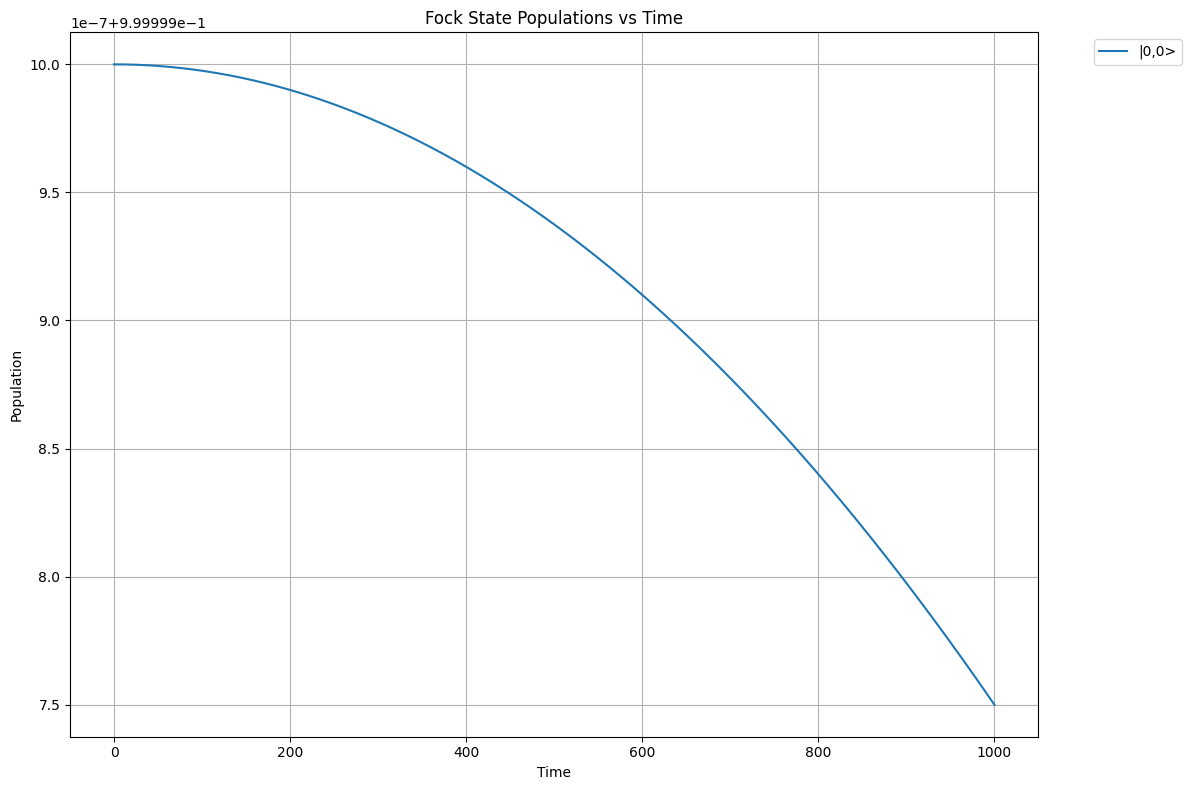

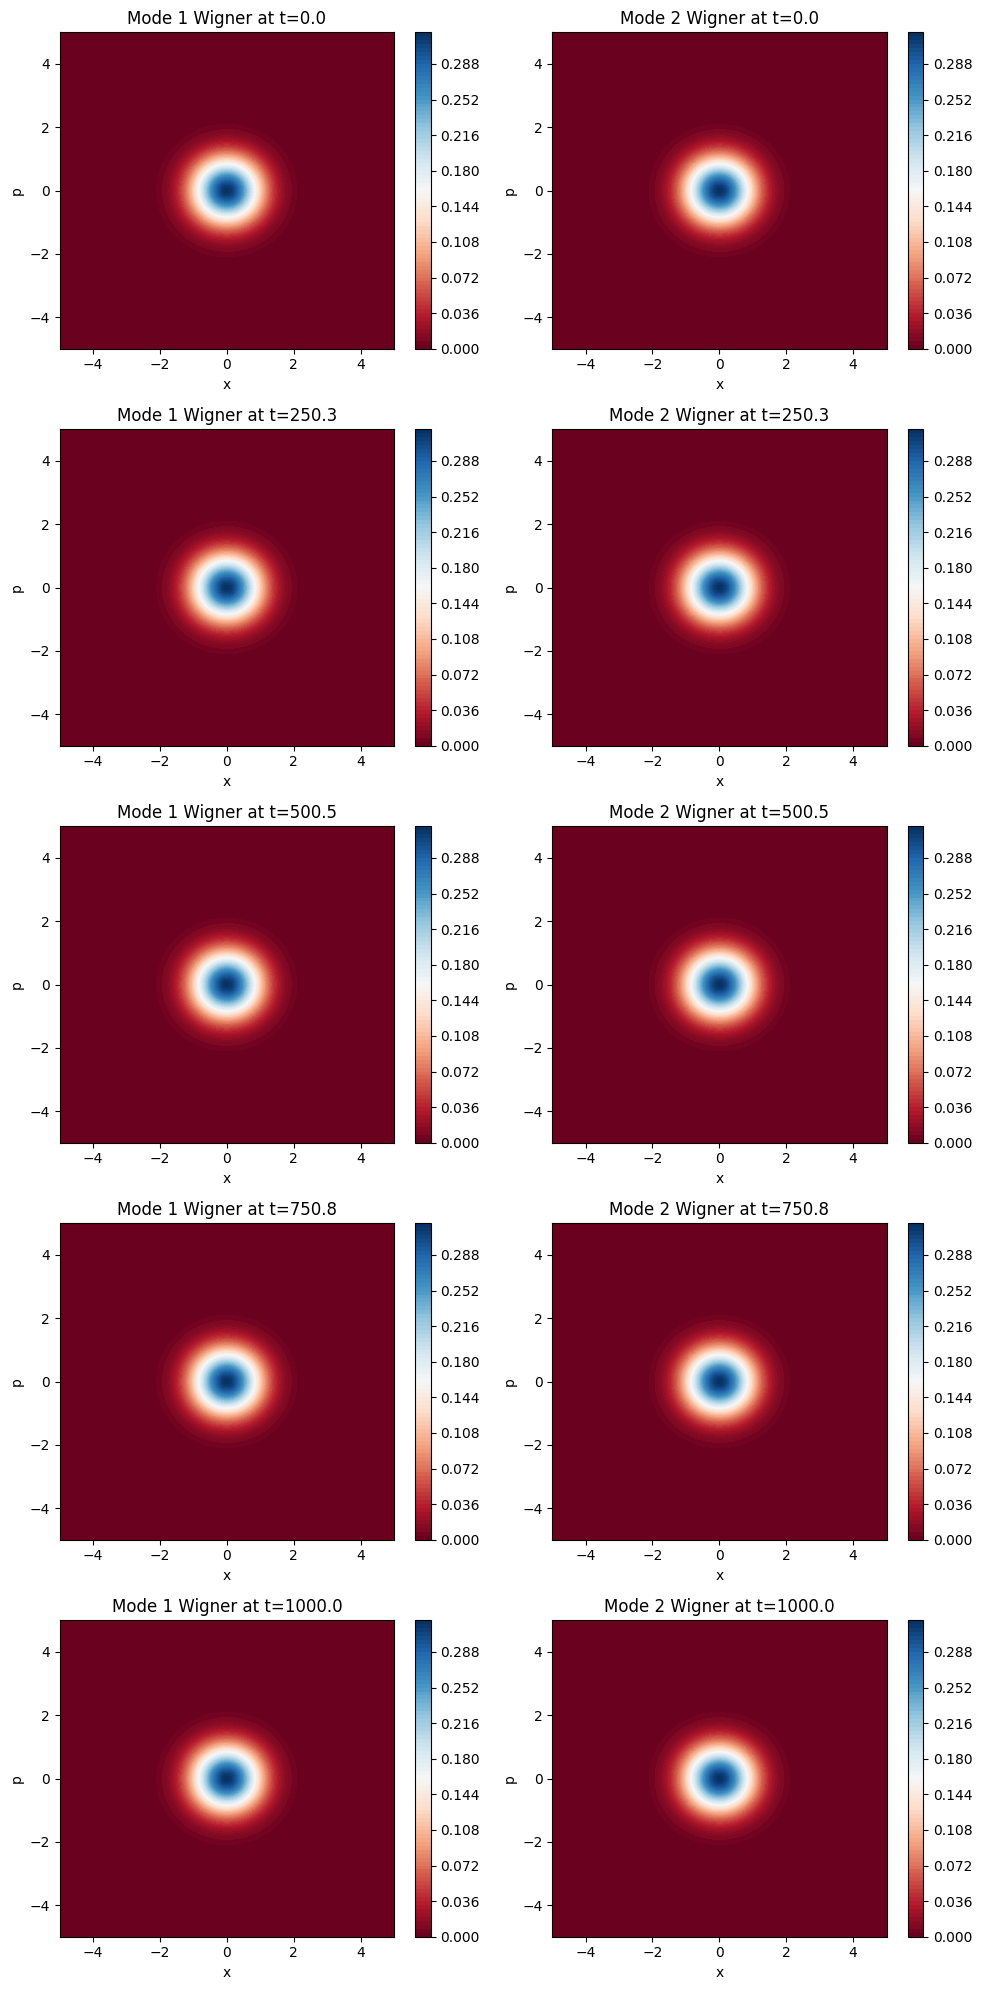

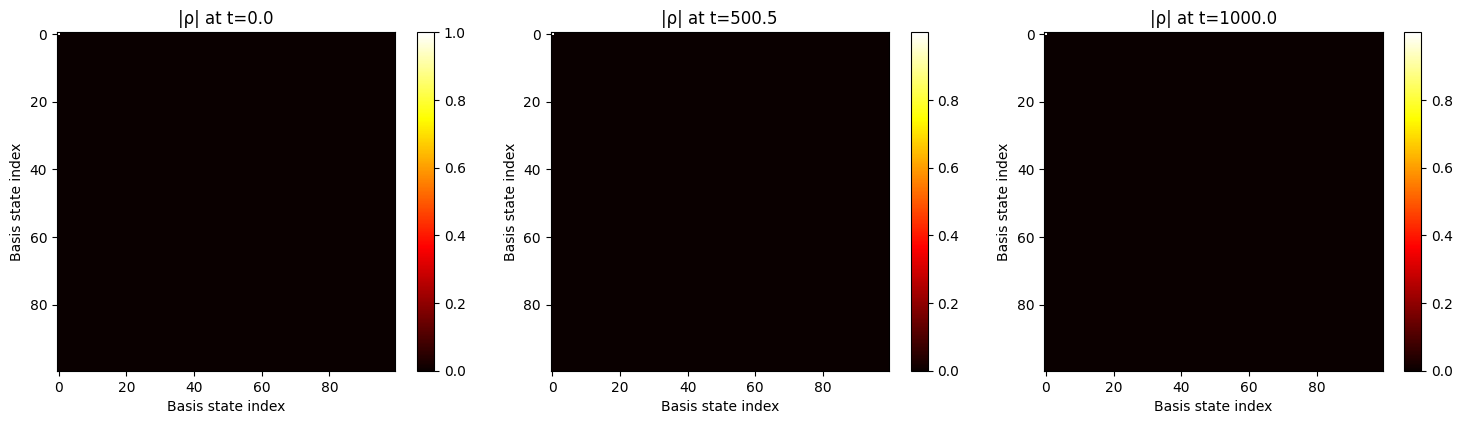

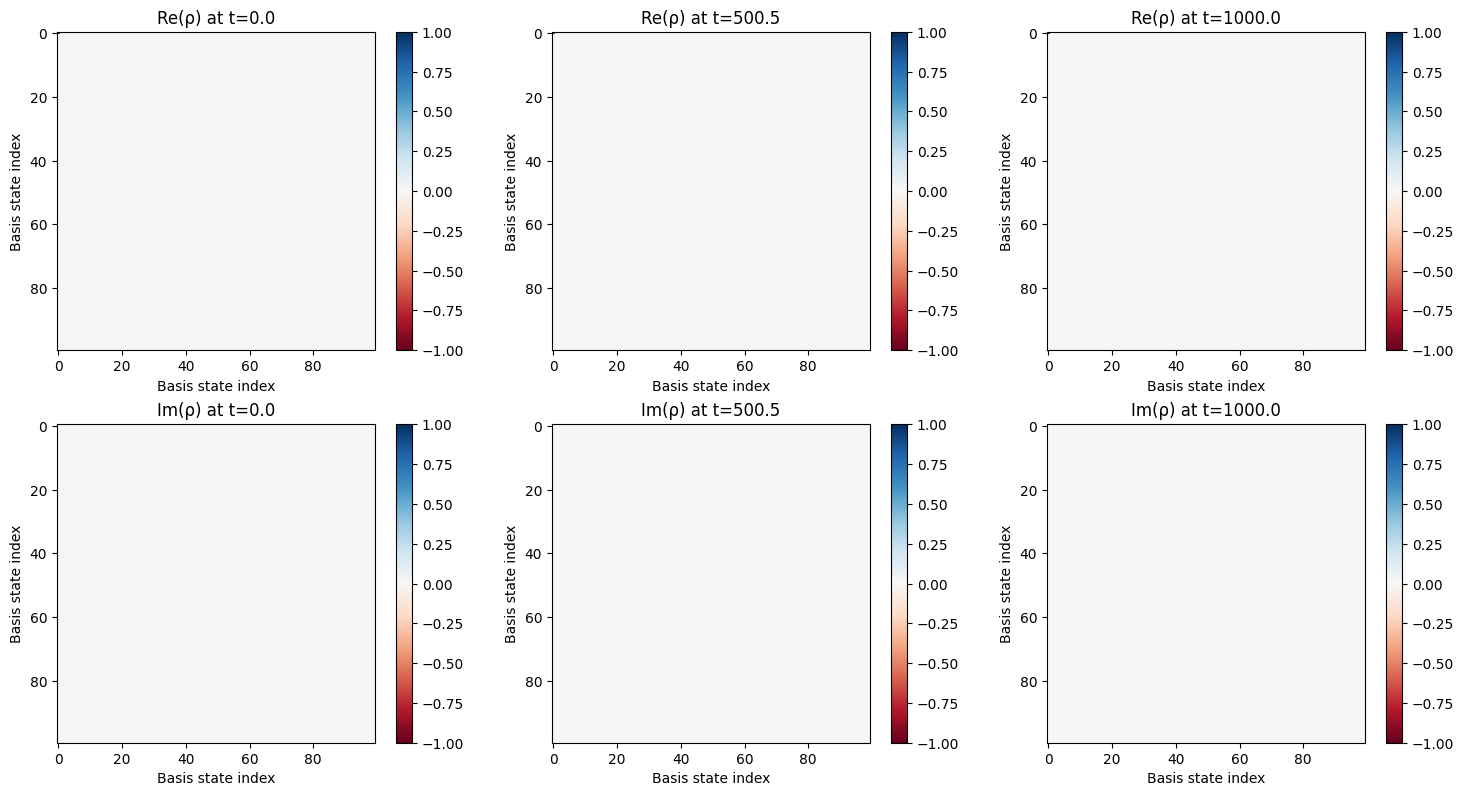

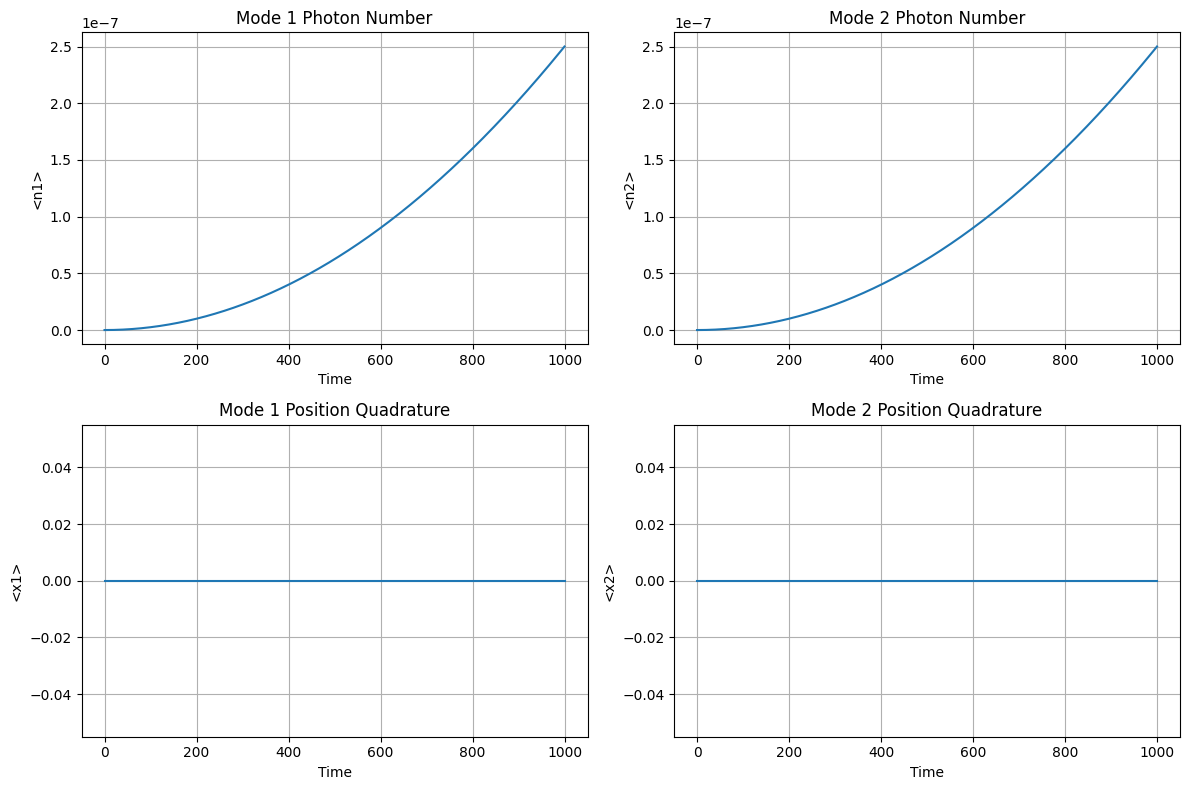

/tmp/ipython-input-9-303421058.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


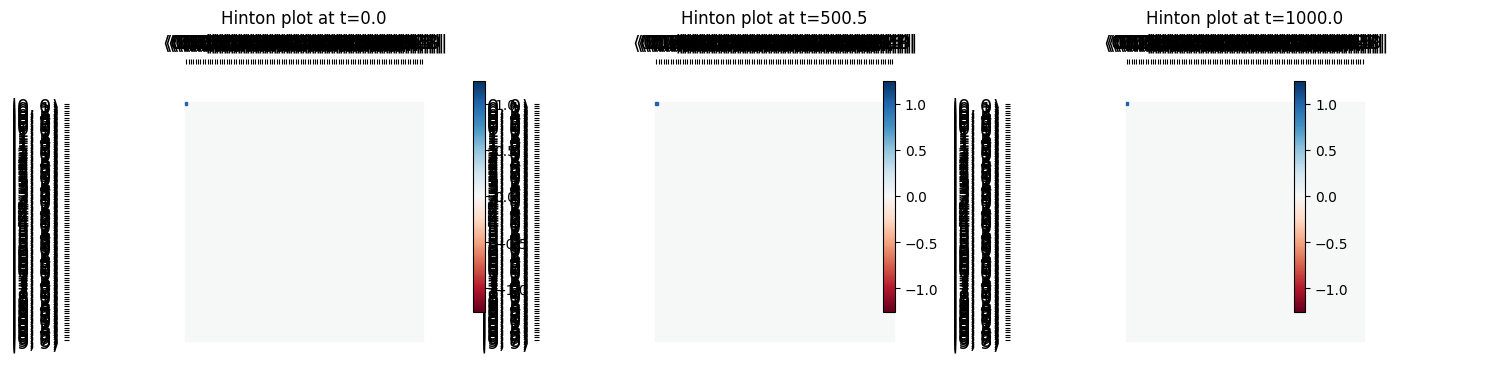

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# After your mesolve calculation, add these visualizations:

# 1. Plot Fock state populations over time
# Calculate populations for different Fock states
n_fock_states = 5  # number of Fock states to plot for each mode

# Create operators for measuring populations
populations = []
labels = []
for i in range(n_fock_states):
    for j in range(n_fock_states):
        # Create projection operator for state |i>|j>
        proj = tensor(basis(N1, i) * basis(N1, i).dag(),
                     basis(N2, j) * basis(N2, j).dag())
        populations.append(expect(proj, psi_out.states))
        labels.append(f"|{i},{j}>")

# Plot populations
plt.figure(figsize=(12, 8))
for i, (pop, label) in enumerate(zip(populations, labels)):
    if max(pop) > 0.01:  # Only plot significant populations
        plt.plot(tlist, pop, label=label)
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Fock State Populations vs Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Visualize Wigner functions at specific times
times_to_plot = [0, 250, 500, 750, 999]  # indices in tlist
xvec = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(len(times_to_plot), 2, figsize=(10, 4*len(times_to_plot)))
if len(times_to_plot) == 1:
    axes = axes.reshape(1, -1)

for idx, t_idx in enumerate(times_to_plot):
    # Get the state at this time
    psi_t = psi_out.states[t_idx]

    # Reduced density matrices for each mode
    rho1 = ptrace(psi_t, 0)  # trace out mode 2
    rho2 = ptrace(psi_t, 1)  # trace out mode 1

    # Wigner function for mode 1
    W1 = wigner(rho1, xvec, xvec)
    cont1 = axes[idx, 0].contourf(xvec, xvec, W1, 100, cmap='RdBu')
    axes[idx, 0].set_title(f'Mode 1 Wigner at t={tlist[t_idx]:.1f}')
    axes[idx, 0].set_xlabel('x')
    axes[idx, 0].set_ylabel('p')
    plt.colorbar(cont1, ax=axes[idx, 0])

    # Wigner function for mode 2
    W2 = wigner(rho2, xvec, xvec)
    cont2 = axes[idx, 1].contourf(xvec, xvec, W2, 100, cmap='RdBu')
    axes[idx, 1].set_title(f'Mode 2 Wigner at t={tlist[t_idx]:.1f}')
    axes[idx, 1].set_xlabel('x')
    axes[idx, 1].set_ylabel('p')
    plt.colorbar(cont2, ax=axes[idx, 1])

plt.tight_layout()
plt.show()

# 3. Plot the density matrix at specific times (FIXED VERSION)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
times_to_plot_dm = [0, 500, 999]

for idx, t_idx in enumerate(times_to_plot_dm):
    psi_t = psi_out.states[t_idx]
    rho = psi_t * psi_t.dag()

    # Plot absolute value of density matrix
    im = axes[idx].imshow(np.abs(rho.full()), cmap='hot', interpolation='nearest')
    axes[idx].set_title(f'|ρ| at t={tlist[t_idx]:.1f}')
    axes[idx].set_xlabel('Basis state index')
    axes[idx].set_ylabel('Basis state index')
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

# 4. Alternative: Plot real and imaginary parts of density matrix
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
times_to_plot_dm = [0, 500, 999]

for idx, t_idx in enumerate(times_to_plot_dm):
    psi_t = psi_out.states[t_idx]
    rho = psi_t * psi_t.dag()

    # Plot real part
    im_real = axes[0, idx].imshow(rho.full().real, cmap='RdBu', interpolation='nearest',
                                  vmin=-1, vmax=1)
    axes[0, idx].set_title(f'Re(ρ) at t={tlist[t_idx]:.1f}')
    axes[0, idx].set_xlabel('Basis state index')
    axes[0, idx].set_ylabel('Basis state index')
    plt.colorbar(im_real, ax=axes[0, idx])

    # Plot imaginary part
    im_imag = axes[1, idx].imshow(rho.full().imag, cmap='RdBu', interpolation='nearest',
                                  vmin=-1, vmax=1)
    axes[1, idx].set_title(f'Im(ρ) at t={tlist[t_idx]:.1f}')
    axes[1, idx].set_xlabel('Basis state index')
    axes[1, idx].set_ylabel('Basis state index')
    plt.colorbar(im_imag, ax=axes[1, idx])

plt.tight_layout()
plt.show()

# 5. Plot expectation values
# Number operators
n1 = tensor(num(N1), qeye(N2))
n2 = tensor(qeye(N1), num(N2))

# Position and momentum quadratures
a1 = tensor(destroy(N1), qeye(N2))
a2 = tensor(qeye(N1), destroy(N2))
x1 = (a1 + a1.dag()) / np.sqrt(2)
x2 = (a2 + a2.dag()) / np.sqrt(2)
p1 = -1j * (a1 - a1.dag()) / np.sqrt(2)
p2 = -1j * (a2 - a2.dag()) / np.sqrt(2)

# Calculate expectation values
n1_exp = expect(n1, psi_out.states)
n2_exp = expect(n2, psi_out.states)
x1_exp = expect(x1, psi_out.states)
x2_exp = expect(x2, psi_out.states)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(tlist, n1_exp)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('<n1>')
axes[0, 0].set_title('Mode 1 Photon Number')
axes[0, 0].grid(True)

axes[0, 1].plot(tlist, n2_exp)
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('<n2>')
axes[0, 1].set_title('Mode 2 Photon Number')
axes[0, 1].grid(True)

axes[1, 0].plot(tlist, x1_exp)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('<x1>')
axes[1, 0].set_title('Mode 1 Position Quadrature')
axes[1, 0].grid(True)

axes[1, 1].plot(tlist, x2_exp)
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('<x2>')
axes[1, 1].set_title('Mode 2 Position Quadrature')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 6. BONUS: Create a hinton plot (if you have qutip.visualization available)
try:
    from qutip.visualization import hinton
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    times_to_plot_hinton = [0, 500, 999]

    for idx, t_idx in enumerate(times_to_plot_hinton):
        psi_t = psi_out.states[t_idx]
        rho = psi_t * psi_t.dag()
        hinton(rho, ax=axes[idx])
        axes[idx].set_title(f'Hinton plot at t={tlist[t_idx]:.1f}')

    plt.tight_layout()
    plt.show()
except ImportError:
    print("Hinton plot not available in your QuTiP version")

### Exercise

 a. Define operator objects for the number operators $\hat{N}$ in $a$ and $b$, as well as the operator for $\hat{N}^2$ for $a$ and $b$.

 b.  Verify the Hermiticity of the Hamiltonian.

 c. Use the `expect()` function to evaluate the expectation of the photon number in $a$ and $b$ for all of the output states, provided by `phi_out.states`.  You should have `1000` output states, one for each point in time in `tlist`.  Plot the growth of the photon number as a function of time.  Does it makes sense? (Compare directly to your expected expression from the pre-lab).

 d. Now calculate the standard deviation of the photon number in $a$ and $b$.  Explain the nature of the growth of the standard deviation.  Does it also match expectations?  Explain why this growth behavior make sense?

 e. The photon rate can be expressed as the phase-matching bandwidth times the photon number which provies the output photons per second.  Given the maximum value at the final time in the interaction, what is the photon emission rate?  How does this compare to the incident pump photon rate assuming a pump wavelength of 400 nm and power of 10 mW?  

The code block below gets you started.  If needed, a refresher on photon number operators and photon number statistics is provided in [BASICS -- Quantum Optics](content-basics-quantum-optics).



In [ ]:
# Import necessary libraries
from qutip import tensor, destroy, qeye, basis, mesolve, expect
import numpy as np
import matplotlib.pyplot as plt

# Constants and Parameters (Already given)
chi = 1e-6  # Strength of nonlinearity
N1 = 10  # Number of photon orders in Fock state basis for a
N2 = 10  # Number of photon orders in Fock state basis for b

#(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b

print("""(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b""")

# Hamiltonian Definition (Already given)
Hab = 1j * chi * (a.dag() * b.dag() - a * b) / 2

# Verify the Hermiticity of the Hamiltonian
H_herm = Hab - Hab.dag()  # .... what should this be if the operator is Hermitian?

(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b


##Solutions

(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b
(b) Hamiltonian Hermiticity Check (should be near zero matrix): Quantum object: dims=[[10, 10], [10, 10]], shape=(100, 100), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


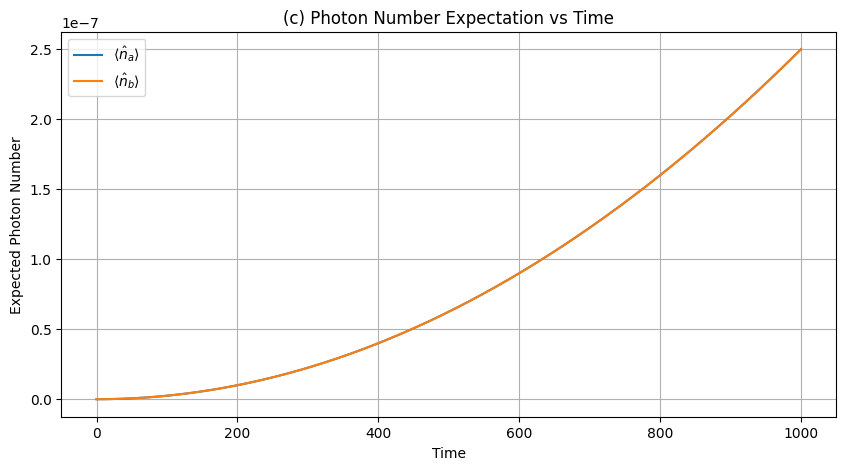

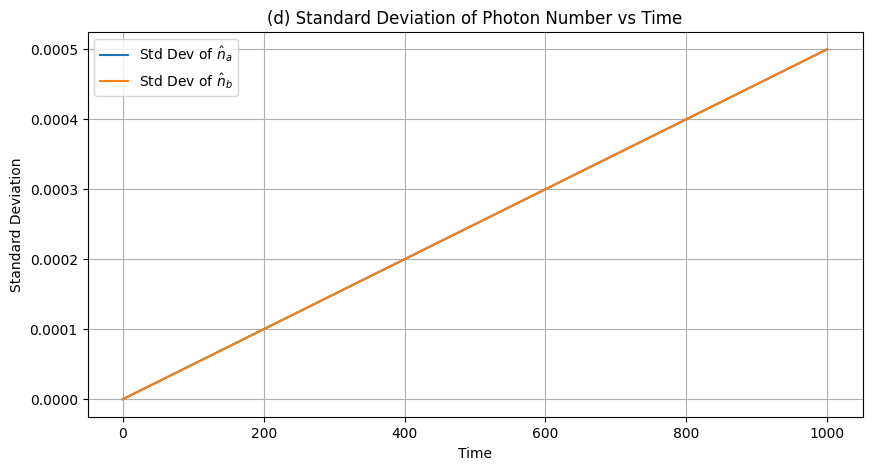

TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [ ]:
# Import necessary libraries
from qutip import tensor, destroy, qeye, basis, mesolve, expect
import numpy as np
import matplotlib.pyplot as plt

# Constants and Parameters (Already given)
chi = 1e-6  # Strength of nonlinearity
N1 = 10  # Number of photon orders in Fock state basis for a
N2 = 10  # Number of photon orders in Fock state basis for b

#(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b

print("""(a)  Operator Definitions (Already given)
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
na = a.dag() * a
nb = b.dag() * b""")

# Hamiltonian Definition (Already given)
Hab = 1j * chi * (a.dag() * b.dag() - a * b) / 2

# Verify the Hermiticity of the Hamiltonian
H_herm = Hab - Hab.dag()  # This should be zero if Hab is Hermitian
print("(b) Hamiltonian Hermiticity Check (should be near zero matrix):", H_herm)

# Initial State and Time List (Already given)
psi0 = tensor(basis(N1, 0), basis(N2, 0))
tlist = np.linspace(0, 1000, 1000)

# Solve the Quantum Master Equation
psi_out = mesolve(Hab, psi0, tlist, [], [])

# Evaluate expectation of the photon number
e_na = expect(na, psi_out.states)
e_nb = expect(nb, psi_out.states)

# Plot the growth of the photon number as a function of time
plt.figure(figsize=(10, 5))
plt.plot(tlist, e_na, label='$\\langle \\hat{n}_a \\rangle$')
plt.plot(tlist, e_nb, label='$\\langle \\hat{n}_b \\rangle$')
plt.xlabel('Time')
plt.ylabel('Expected Photon Number')
plt.title('(c) Photon Number Expectation vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Calculate the standard deviation of the photon number
na2 = (a.dag() * a) ** 2  # operator for na squared
nb2 = (b.dag() * b) ** 2  # operator for nb squared
e_na2 = expect(na2, psi_out.states)
e_nb2 = expect(nb2, psi_out.states)
std_dev_na = np.sqrt(e_na2 - np.square(e_na))
std_dev_nb = np.sqrt(e_nb2 - np.square(e_nb))

# Plot standard deviation of photon numbers
plt.figure(figsize=(10, 5))
plt.plot(tlist, std_dev_na, label='Std Dev of $\\hat{n}_a$')
plt.plot(tlist, std_dev_nb, label='Std Dev of $\\hat{n}_b$')
plt.xlabel('Time')
plt.ylabel('Standard Deviation')
plt.title('(d) Standard Deviation of Photon Number vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Photon emission rate calculation
max_photon_number = max(e_na[-1], e_nb[-1])  # max photon number at final time
phase_matching_bandwidth = 1e13  # Hz
photon_emission_rate = phase_matching_bandwidth * max_photon_number
print(f"Photon Emission Rate: {photon_emission_rate} photons/s")

# Incident pump photon rate calculation
h = 6.62607015e-34  # Planck's constant
c = 299792458  # Speed of light in m/s
lambda_pump = 400e-9  # Pump wavelength in meters
power_pump = 10e-3  # Power in watts
energy_per_photon = h * c / lambda_pump
pump_photon_rate = power_pump / energy_per_photon
print(f"(e) Incident Pump Photon Rate: {pump_photon_rate} photons/s")

# Compare photon emission rate to pump photon rate
print(f"Photon emission rate is {photon_emission_rate / pump_photon_rate:.2e} times the incident pump photon rate.")


## State evolution

Next, we will plot the photon distributions of two quantum optical modes a and b at selected times.

The time indices are spaced over the number of time steps in `tlist`.  

The following subplots show the state evolution (note the plots have shared horizontal and vertical axes). We represent the photon distributions as bar plots on the subplots.

Only single-photon pairs in $a$ and $b$ are generated at a non-neglibile rate (but are still far fewer than the number of incident pump photons), with neglible amounts of higher order Fock state generation.

interactive(children=(IntSlider(value=30, continuous_update=False, description='Time index:', max=999), Output…

<function __main__.update_plot(t)>

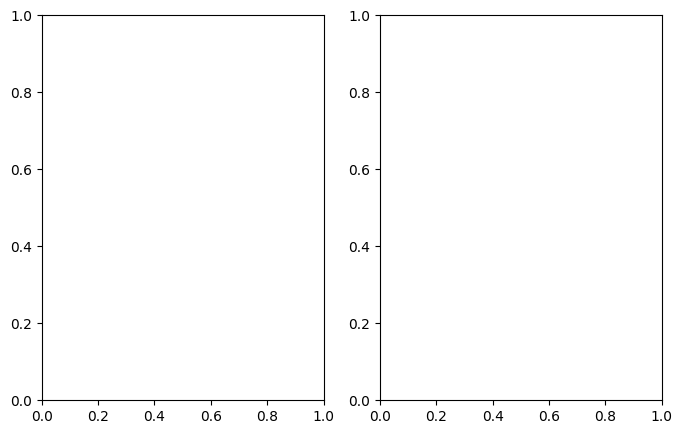

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from numpy import real
from qutip import ptrace

# Assuming N1, N2, and psi_out are defined as per your context
xmin, xmax = 0, 5

def update_plot(t):
    clear_output(wait=True)  # Clears the output area (including plots), and wait for new output
    fig, axes = plt.subplots(1, 2, figsize=(8, 5))
    psia = ptrace(psi_out.states[t], 0)  # Trace out system b, leaving system a
    psib = ptrace(psi_out.states[t], 1)  # Trace out system a, leaving system b
    bar_vals_a = real(psia.diag())
    bar_vals_b = real(psib.diag())
    max_val = max(bar_vals_a[1:].max(), bar_vals_b[1:].max())  # ignore the vacuum state when setting scale
    axes[0].bar(range(N1), bar_vals_a)
    axes[1].bar(range(N2), bar_vals_b)
    axes[0].set_ylabel('$P(n)$')
    axes[1].set_ylabel('$P(n)$')
    axes[0].set_xlabel('$n_a$')
    axes[1].set_xlabel('$n_b$')
    axes[0].set_yscale('log')
    axes[1].set_yscale('log')
    axes[0].set_ylim(bottom=10**-12, top=max_val*1.2)
    axes[1].set_ylim(bottom=10**-12, top=max_val*1.2)
    axes[0].set_xlim(xmin, xmax)
    axes[1].set_xlim(xmin, xmax)

    display(fig)  # Display the figure
    plt.close(fig)  # Close the figure environment to prevent display in non-interactive contexts

widgets.interact(update_plot, t=widgets.IntSlider(min=0, max=len(tlist)-1, step=1, value=30, description='Time index:', continuous_update=False))


## Exercise

Increase the coupling term, $\chi$ and redo the above state visualization.  What happens in terms of the photon number distribution when $\chi$ becomes large?  Does the analytical solution still hold?

## Solution

### Expected Changes in Photon Number Distribution
1. **Faster Dynamics**: As $\chi$ increases, the rate at which photon pairs are generated should increase by $|\chi|^{2}\propto $ the pump power.

2. **Higher Photon Numbers**: With a larger $\chi$, you're more likely to see significant populations in higher photon-number states within a given time frame. This is because the stronger coupling makes it more likely for multiple down-conversion events to occur within shorter times.

3. **Breakdown of Linear Approximations**: In cases where the coupling is weak, certain approximations (like perturbative approaches) hold well. However, as $\chi$ becomes large, these approximations can break down, and the system may need to be described with a full nonlinear approach.

4. **Possible Departure from Analytical Predictions**: If the analytical solution you mentioned earlier assumes weak coupling or other simplifications, increasing $\chi$ might lead to discrepancies between the predicted and actual behavior. For instance, higher order terms that were negligible at lower $\chi$ values might become significant, affecting both the state evolution and the photon number statistics.


### Experimenting with Increased $\chi$:
To visualize and understand the impact of an increased $\chi$ in your QuTiP simulation, you can adjust the $\chi$ value in your Hamiltonian and rerun the simulation and plotting code. Here’s how you might modify the existing code to explore a larger $\chi$:


In [ ]:
# Import necessary libraries
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from numpy import real
from qutip import tensor, destroy, qeye, basis, mesolve, ptrace

# Constants and Parameters
N1 = 10  # Number of photon orders in Fock state basis for mode a
N2 = 10  # Number of photon orders in Fock state basis for mode b
a = tensor(destroy(N1), qeye(N2))
b = tensor(qeye(N1), destroy(N2))
psi0 = tensor(basis(N1, 0), basis(N2, 0))  # Initial state
tlist = np.linspace(0, 1000, 1000)  # Time list

# Default values
default_chi = 1e-6  # Default coupling constant
default_power = 10  # Default pump power in mW
current_power = default_power  # Initialize current_power

# Function to compute the system evolution
def compute_evolution(power):
    chi = default_chi * (power / default_power)  # Adjust chi proportionally to power
    Hab = 1j * chi * (a.dag() * b.dag() - a * b) / 2
    return mesolve(Hab, psi0, tlist, [], [])

# Current output based on default power
psi_out_current = compute_evolution(default_power)

# Plot function
def update_plot(t, power):
    global psi_out_current, current_power
    clear_output(wait=True)
    if psi_out_current is None or current_power != power:
        psi_out_current = compute_evolution(power)  # Recompute only if power changes
        current_power = power  # Update the current power
    fig, axes = plt.subplots(1, 2, figsize=(8, 5))
    psia = ptrace(psi_out_current.states[t], 0)
    psib = ptrace(psi_out_current.states[t], 1)
    bar_vals_a = real(psia.diag())
    bar_vals_b = real(psib.diag())
    max_val = max(bar_vals_a[1:].max(), bar_vals_b[1:].max())  # ignore the vacuum state when setting scale
    axes[0].bar(range(N1), bar_vals_a)
    axes[1].bar(range(N2), bar_vals_b)
    axes[0].set_ylabel('$P(n)$')
    axes[1].set_ylabel('$P(n)$')
    axes[0].set_xlabel('$n_a$')
    axes[1].set_xlabel('$n_b$')
    axes[0].set_yscale('log')
    axes[1].set_yscale('log')
    axes[0].set_ylim(bottom=10**-8, top=max_val*1.2)
    axes[1].set_ylim(bottom=10**-8, top=max_val*1.2)
    axes[0].set_xlim(0, 5)
    axes[1].set_xlim(0, 5)

    display(fig)
    plt.close(fig)

# Widget setup
time_slider = widgets.IntSlider(min=0, max=len(tlist)-1, step=1, value=30, description='Time index:')
power_slider = widgets.FloatSlider(min=1, max=100, step=1, value=default_power, description='Pump Power (mW):')

# Display widgets and plots interactively
widgets.interact(update_plot, t=time_slider, power=power_slider)


interactive(children=(IntSlider(value=30, description='Time index:', max=999), FloatSlider(value=10.0, descrip…

<function __main__.update_plot(t, power)>

## Second-order coherence

Here we examine the generated photon statistics further by looking at the second order correlation function of photons in the outgoing modes $a$ and $b$.  

Classical fields satisfy the Cauchy-Schwarz inequality evaluated at the same time $t$ on both detectors (Walls and Milburn, page 79).  This can be expressed with respect to the second order correlation functions of the output state at time $t$ as:

$$(g^{(2)}_{ab})^2 \leq g^{(2)}_{aa} g^{(2)}_{bb}$$

where

$$g^{(2)}_{ab} = \frac{\langle \hat{a}^\dagger \hat{a} \hat{b}^\dagger \hat{b} \rangle}{\langle \hat{a}^\dagger \hat{a} \rangle \langle \hat{b}^\dagger \hat{b}\rangle} $$

and

$$g^{(2)}_{aa} = \frac{\langle \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} \rangle}{\langle \hat{a}^\dagger \hat{a} \rangle ^2} $$

and likewise for $g^{(2)}_{bb}$.  

Let's explore this further in the following.

## Exercise



a.   Using the same procedure as for the photon number expectation calculations, now calculate and plot the second order correlation functions for $g^{(2)}_{aa}$, $g^{(2)}_{bb}$, and $g^{(2)}_{ab}$.  
b.   Is the Cauchy-Schwarz inequality broken?  
c.   You should find that the photon correlations of the fields produced from a vacuum passing through the parametric amplifier are not just strongly nonclassical but actually saturate the bound on the maximum allowed by quantum mechanics.  Discuss why this makes SPDC a valuable resource from the context of quantum technologies.

### Solution

Let's first outline how to calculate and plot the second-order correlation functions using QuTiP, and then discuss the implications and whether the Cauchy-Schwarz inequality is violated in the context of spontaneous parametric down-conversion (SPDC).  

#### Calculating Second-Order Correlation Functions

### Second-order coherence functions

Walls and Milburn, page 79: Classical fields satisfy the Cauchy-Schwartz inequality evaluated at the same time $t$ on both detectors, i.e., $$ \langle \psi_{out}(t) | a_1^{\dagger} a_1 a_2^{\dagger}  a_2 | \psi_{out}(t) \rangle \leq \langle (a_1^{\dagger})^{2}  (a_1)^{2}  \rangle_t $$, or equivalently

$$(g_{12}^{(2)})_{t}^2 \leq (g_{1}^{(2)}g_{2}^{(2)})_{t}$$.

Plotting the correlation functions, we see a strong violation of the Cauchy-Schwartz inequality in the weak-pump limit. In fact, the photon correlations of the squeezed fields produced from a vacuum passing through the parametric amplifier are not just strongly nonclassical but actually saturate the bound on the maximum allowed by quantum mechanics.



In [ ]:
#[code transfer in progress] -- ask Prof Englund for separate code for now

# import matplotlib.pyplot as plt
# import numpy as np

# # Assuming tlist and expected_vals_dict have been defined previously in your computation
# fig, axes = plt.subplots(2, 2, figsize=(8, 5))
# background = 1e-30
# plot_fontsize = 12

# # Dictionary mapping the plot labels and data from your results
# quantities_dict = {
#     "g_aa": [r'$g_{aa}^{(2)}(t)$', ((expected_vals_dict["ad_ad_a_a"]) / (background**2 + expected_vals_dict["na"]**2))],
#     "g_bb": [r'$g_{bb}^{(2)}(t)$', ((expected_vals_dict["bd_bd_b_b"]) / (background**2 + expected_vals_dict["nb"]**2))],
#     "g_ab": [r'$g_{ab}^{(2)}(t)$', ((expected_vals_dict["ad_a_bd_b"]) / (background**2 + expected_vals_dict["na"] * expected_vals_dict["nb"]))],
#     "g_ab_squared": [r'$(g_{ab}^{(2)}(t))^2$', ((expected_vals_dict["ad_a_bd_b"]) / (background**2 + expected_vals_dict["na"] * expected_vals_dict["nb"]))**2]
# }

# # Plotting each quantity in the appropriate subplot
# for idx, (quantity_key, (ylabel, data)) in enumerate(quantities_dict.items()):
#     ax = axes[idx // 2, idx % 2]  # Determine the correct subplot
#     ax.plot(tlist, data, 'rx', linewidth=2)  # Plot the data
#     ax.set_xlabel("$t$", fontsize=plot_fontsize)  # Set x-axis label
#     ax.set_xlim(1, 20)  # Set the x-axis limits
#     ax.set_ylabel(ylabel, fontsize=plot_fontsize)  # Set y-axis label
#     # Optional: Set y-axis to log scale if data spans several orders of magnitude
#     # ax.set_yscale("log")

# fig.tight_layout()  # Adjust layout for better spacing
# plt.show()  # Display the plot


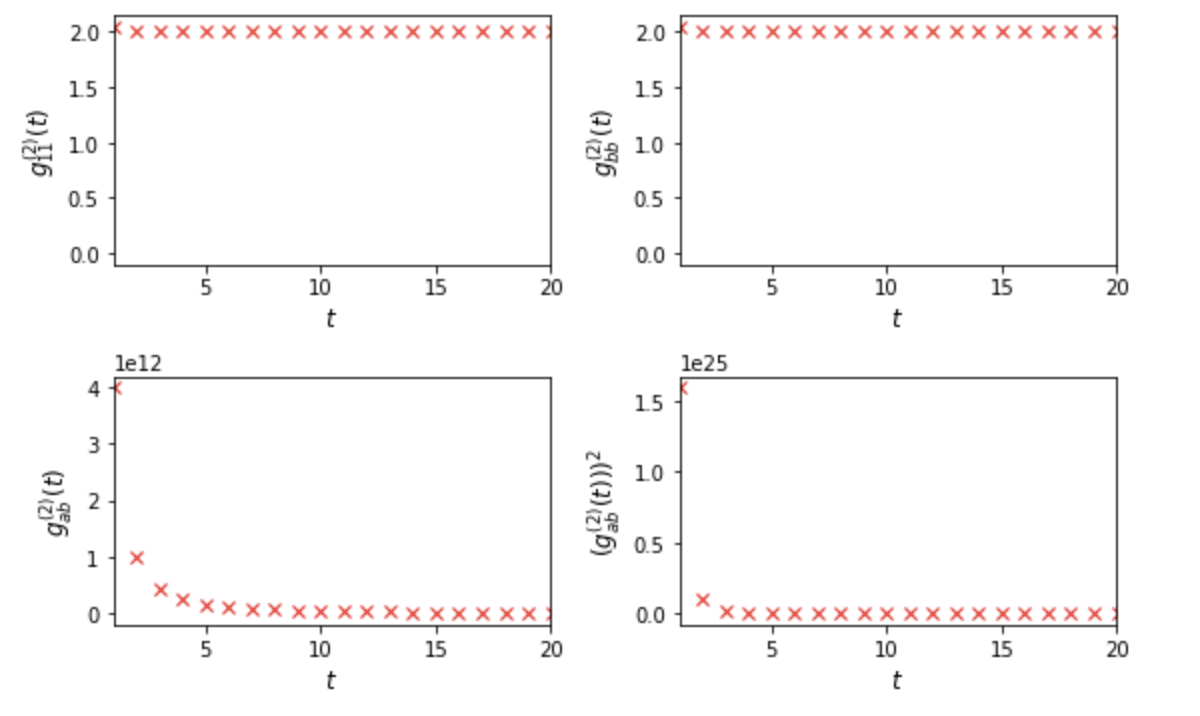

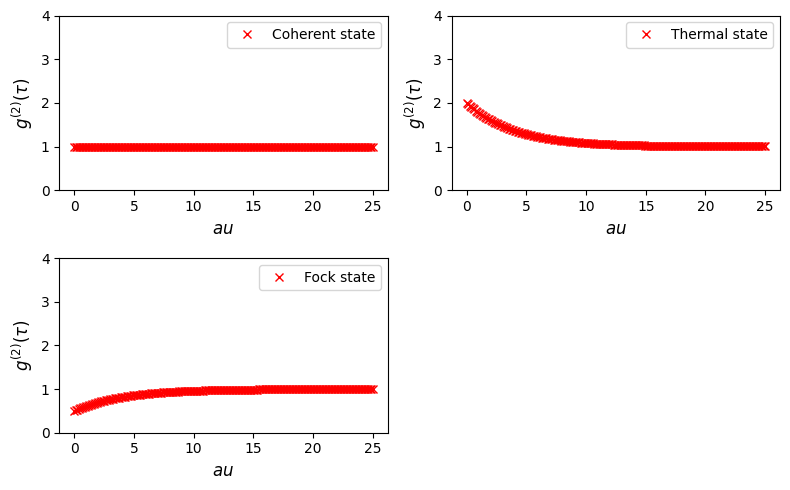

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip

N = 25
taus = np.linspace(0, 25.0, 200)
a = qutip.destroy(N)
H = 2 * np.pi * a.dag() * a

kappa = 0.25
n_th = 2.0  # bath temperature in terms of excitation number
c_ops = [np.sqrt(kappa * (1 + n_th)) * a, np.sqrt(kappa * n_th) * a.dag()]

states = [
    {'state': qutip.coherent_dm(N, np.sqrt(2)), 'label': "Coherent state"},
    {'state': qutip.thermal_dm(N, 2), 'label': "Thermal state"},
    {'state': qutip.fock_dm(N, 2), 'label': "Fock state"}
]

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
background = 1e-30
plot_fontsize = 12

for idx, state in enumerate(states):
    rho0 = state['state']

    # first calculate the occupation number as a function of time
    n = qutip.mesolve(H, rho0, taus, c_ops, [a.dag() * a]).expect[0]

    # calculate the correlation function G2 and normalize with n(0) * n(t) to obtain g2
    G2 = qutip.correlation_3op_1t(H, rho0, taus, c_ops, a.dag(), a.dag() * a, a)
    g2 = G2 / (n[0] * n + background**2)  # Added background to avoid division by zero

    ax = axes[idx//2, idx%2]
    ax.plot(taus, np.real(g2), 'rx', linewidth=2, label=state['label'])
    ax.set_xlabel("$\tau$", fontsize=plot_fontsize)
    ax.set_ylabel(r'$g^{(2)}(\tau)$', fontsize=plot_fontsize)
    ax.set_ylim(bottom=0 , top=4)
    ax.legend()

# Turn off unused subplot if the number of plots is odd
if len(states) % 2 != 0:
    axes[-1, -1].axis('off')

fig.tight_layout()
plt.show()


## Advanced optic: Degenerate SPDC and Squeezing

Two-photon states generated by degenerate SPDC sources (*i.e.* SPDC sources where the signal and idler share a single output mode) exhibit squeezing (see [](sec:quantum-optics-basics:squeezed-states)).  In fact, similar processes to what you are modeling are used to generate bright squeezed light that is enabling ultra-precise interferometric measurements.  To see how squeezed states can be used to reduce the readout noise of an interferometer, see [](content-t3e1-extras-homodyne-detection).

**a.** Implement a degenerate SPDC where both photons emitted into a single mode. This is decribed by the Hamiltonain

$$\hat{H}_{aa} = i \hbar \frac{\chi}{2} (\hat{a}^{\dagger2} - \hat{a}^2)$$

Use the same settings as above for the non-degenerate SPDC generation (i.e. same `chi`, `tlist`, etc).

**b.** Calculate and visualize the Wigner function of the output state using QuTiP (`qutip.Wigner`).  The Wigner function helps visualize the field distribution of the outgoing state along the in-phase and quadrature planes.  

**c.** Now increase the nonlinearity setting `chi=5e-4`.  Plot the Wigner function again.  What is the difference? Do you see the hallmarks of squeezing?

In [ ]:
#Wigner function example you can use:

xvec = np.linspace(-4, 4, 100)
W_out = qutip.wigner(psi_out.states[-1], xvec, xvec)
plt.contourf(xvec, xvec, W_out, 100)


### Solution

### a. Implementing Degenerate SPDC

First, let's set up the Hamiltonian for a degenerate SPDC where both photons are emitted into a single mode:



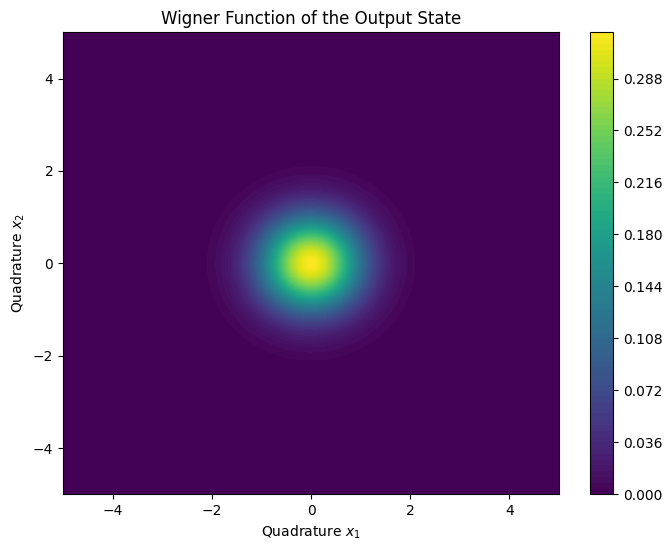

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Parameters
N = 25  # Hilbert space size
chi = 1e-6  # Nonlinearity coefficient
tlist = np.linspace(0, 1, 100)  # Time list for evolution

# Operators
a = qt.destroy(N)
H_aa = 1j * chi / 2 * (a.dag()**2 - a**2)  # Hamiltonian for degenerate SPDC

# Initial state (vacuum state)
psi0 = qt.basis(N, 0)

# Time evolution
result = qt.mesolve(H_aa, psi0, tlist, [], [])

# Visualize the final state using the Wigner function
xvec = np.linspace(-5, 5, 200)
W_out = qt.wigner(result.states[-1], xvec, xvec)
plt.figure(figsize=(8, 6))
plt.contourf(xvec, xvec, W_out, 100)
plt.colorbar()
plt.title("Wigner Function of the Output State")
plt.xlabel("Quadrature $x_1$")
plt.ylabel("Quadrature $x_2$")
plt.show()


### b. Visualizing the Wigner Function of the Output State

We'll calculate and plot the Wigner function for the final state to visualize the quantum state's phase space distribution:



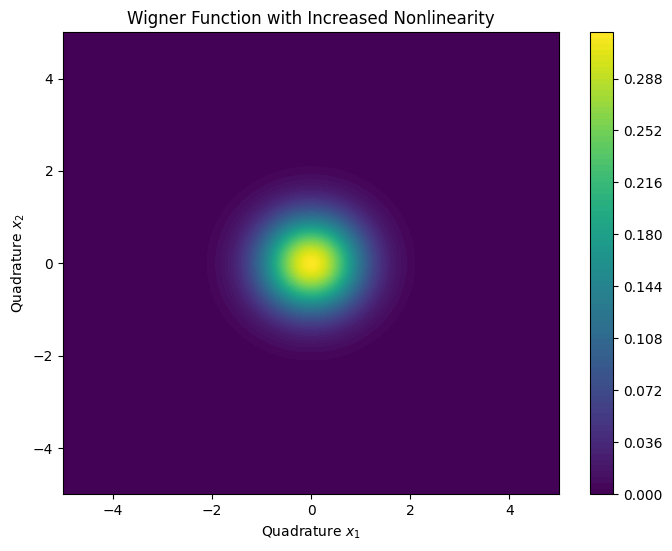

In [ ]:
# Increase the nonlinearity
chi = 5e-4  # Increased nonlinearity coefficient

# Re-define the Hamiltonian with increased nonlinearity
H_aa = 1j * chi / 2 * (a.dag()**2 - a**2)

# Time evolution with increased chi
result_chi_increased = qt.mesolve(H_aa, psi0, tlist, [], [])

# Visualize the final state with increased chi
W_out_increased = qt.wigner(result_chi_increased.states[-1], xvec, xvec)
plt.figure(figsize=(8, 6))
plt.contourf(xvec, xvec, W_out_increased, 100)
plt.colorbar()
plt.title("Wigner Function with Increased Nonlinearity")
plt.xlabel("Quadrature $x_1$")
plt.ylabel("Quadrature $x_2$")
plt.show()



### Bc. Increasing Nonlinearity and Observing Changes

Now, let's increase \(\chi\) to \(5 \times 10^{-4}\) and observe the changes in the Wigner function, particularly looking for signs of squeezing:



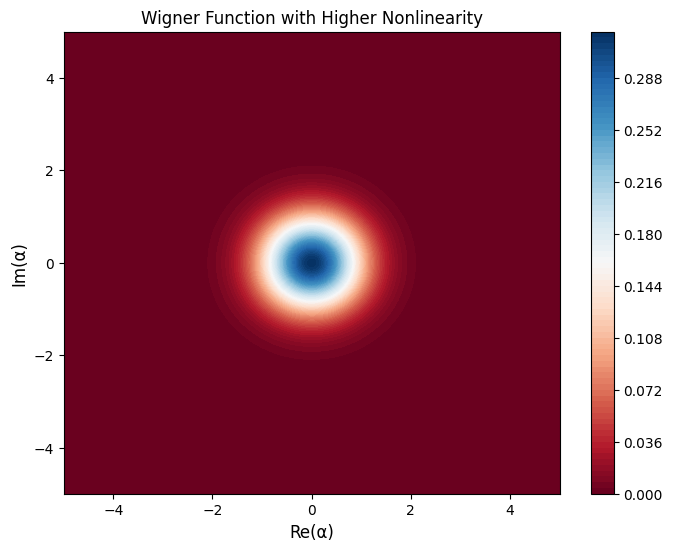

In [ ]:
# Increase chi
chi_high = 5e-4
H_aa_high = 1j * chi_high / 2 * (a.dag()**2 - a**2)

# Time evolution of the state with higher nonlinearity
result_high = mesolve(H_aa_high, psi0, tlist, [], [])
final_state_high = result_high.states[-1]

# Calculate the Wigner function for the new final state
W_high = wigner(final_state_high, xvec, xvec)

# Plot the Wigner function
plt.figure(figsize=(8, 6))
plt.contourf(xvec, xvec, W_high, 100, cmap='RdBu')
plt.colorbar()
plt.xlabel('Re(α)', fontsize=12)
plt.ylabel('Im(α)', fontsize=12)
plt.title('Wigner Function with Higher Nonlinearity')
plt.show()


Now let's generate and plot the Wigner functions for both a squeezed vacuum state and a single-photon Fock state, along with their visualizations.



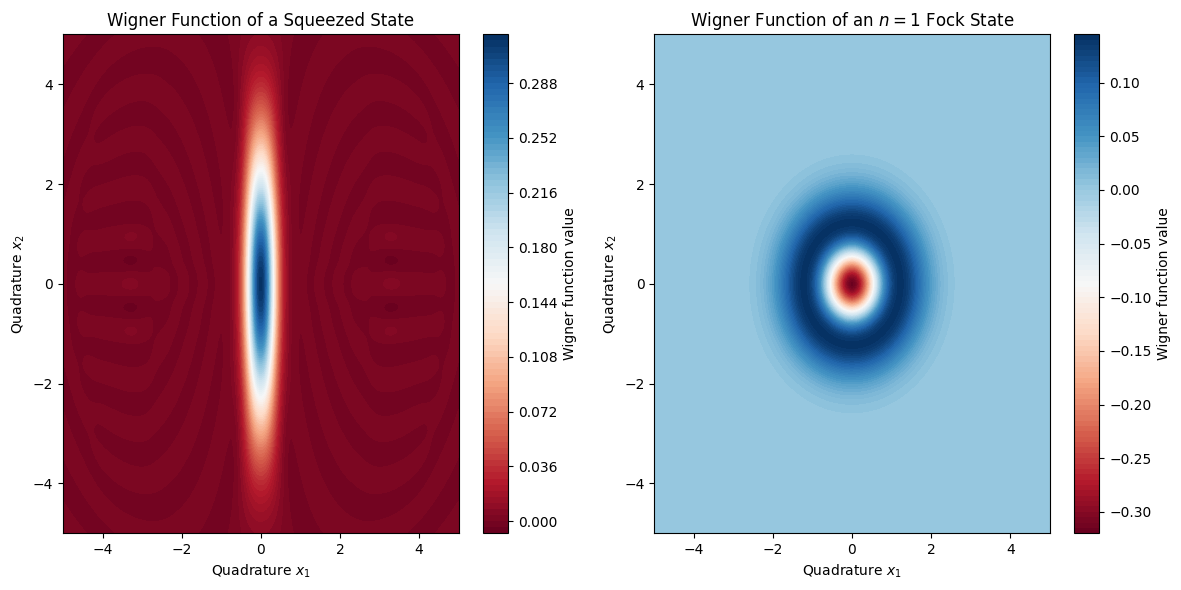

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Parameters
N = 25  # Hilbert space size
squeezing_parameter = 1.0  # Squeezing parameter, r

# Operators
a = qt.destroy(N)

# Squeezed vacuum state
squeezed_state = qt.squeeze(N, squeezing_parameter) * qt.basis(N, 0)

# Fock state n=1
fock_state = qt.basis(N, 1)

# Define the range for the Wigner function calculation
xvec = np.linspace(-5, 5, 200)

# Calculate the Wigner function for the squeezed state
W_squeezed = qt.wigner(squeezed_state, xvec, xvec)

# Calculate the Wigner function for the Fock state
W_fock = qt.wigner(fock_state, xvec, xvec)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Squeezed state Wigner function
contour_squeezed = axes[0].contourf(xvec, xvec, W_squeezed, 100, cmap='RdBu')
fig.colorbar(contour_squeezed, ax=axes[0], label='Wigner function value')
axes[0].set_title('Wigner Function of a Squeezed State')
axes[0].set_xlabel('Quadrature $x_1$')
axes[0].set_ylabel('Quadrature $x_2$')

# Fock state Wigner function
contour_fock = axes[1].contourf(xvec, xvec, W_fock, 100, cmap='RdBu')
fig.colorbar(contour_fock, ax=axes[1], label='Wigner function value')
axes[1].set_title('Wigner Function of an $n=1$ Fock State')
axes[1].set_xlabel('Quadrature $x_1$')
axes[1].set_ylabel('Quadrature $x_2$')

plt.tight_layout()
plt.show()



### Key Observations
- **Squeezed State**: Look for elongation in one quadrature, indicating reduced uncertainty in that direction compared to the orthogonal direction.
- **Fock State**: Expect to see concentric rings with alternating signs, indicative of the quantum nature of the Fock state. The \( n=1 \) Fock state typically shows a central negative dip surrounded by a positive ring.

These visualizations will help you see the differences in quantum characteristics between these states, particularly how squeezing affects the uncertainty in quadratures and how Fock states manifest their quantum properties in phase space.

### Gaussian boson sampling

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N = 25
squeezing_parameter = 1.0

# Create squeezed states
squeezed_vacuum_1 = qt.squeeze(N, squeezing_parameter) * qt.basis(N, 0)
squeezed_vacuum_2 = qt.squeeze(N, squeezing_parameter) * qt.basis(N, 0)

# Create mode operators
a = qt.tensor(qt.destroy(N), qt.qeye(N))
b = qt.tensor(qt.qeye(N), qt.destroy(N))

# Beam splitter unitary transformation
theta = np.pi/4  # Beam splitter angle for 50:50 splitting
U = (a + 1j * b).unit() / np.sqrt(2) + (1j * a + b).unit() / np.sqrt(2)

# Apply the beam splitter transformation
input_state = qt.tensor(squeezed_vacuum_1, squeezed_vacuum_2)
output_state = U * input_state * U.dag()  # Apply the beam splitter

# Calculate Wigner function for the output state of the first mode
xvec = np.linspace(-5, 5, 200)
W_output = qt.wigner(output_state.ptrace(0), xvec, xvec)  # Trace out the second mode

# Plot the Wigner function
plt.figure(figsize=(8, 6))
plt.contourf(xvec, xvec, W_output, 100, cmap='RdBu')
plt.colorbar()
plt.title('Wigner Function of the Output State in a GBS Experiment')
plt.xlabel('Quadrature $x_1$')
plt.ylabel('Quadrature $x_2$')
plt.show()


TypeError: incompatible dimensions [[25, 25], [1, 1]] and [[25, 25], [25, 25]]